performing EDA

In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('Exam_Score_Prediction2.csv')

In [3]:
df.head()


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,200.99,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,200.99,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,200.99,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,200.99,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,200.99,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  float64
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(5), int64(1), object(7)
memory usage: 2.0+ MB


In [5]:
df.tail()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
19995,19800.01,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19800.01,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19800.01,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,19800.01,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0
19999,19800.01,20,male,b.sc,7.50,47.9,yes,7.5,poor,coaching,medium,moderate,71.0


In [6]:
df.shape

(20000, 13)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='study_hours', ylabel='exam_score'>

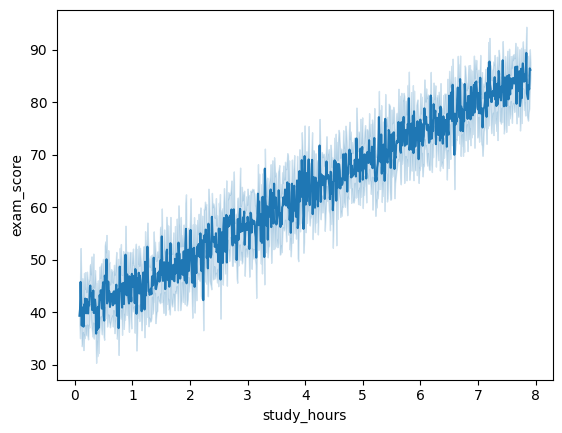

In [8]:
sns.lineplot(data=df, x='study_hours', y='exam_score')

<Axes: xlabel='exam_score', ylabel='class_attendance'>

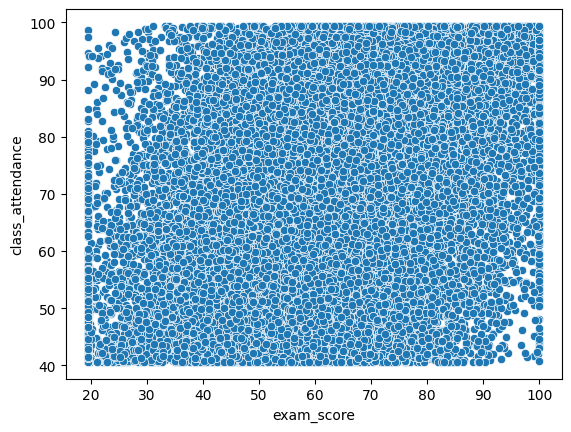

In [9]:
sns.scatterplot(y="class_attendance", x="exam_score", data=df)

<Axes: xlabel='gender', ylabel='count'>

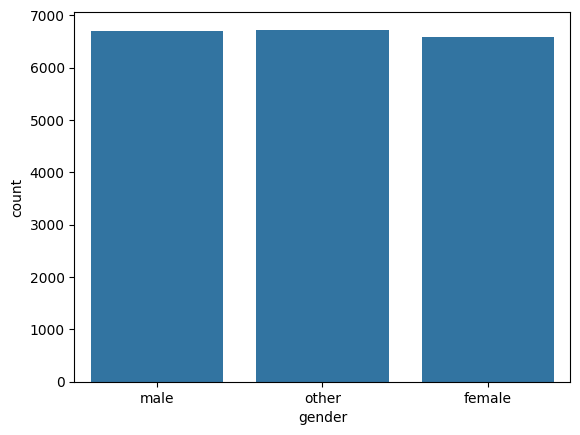

In [10]:
sns.countplot(x="gender", data=df)


<Axes: xlabel='gender', ylabel='exam_score'>

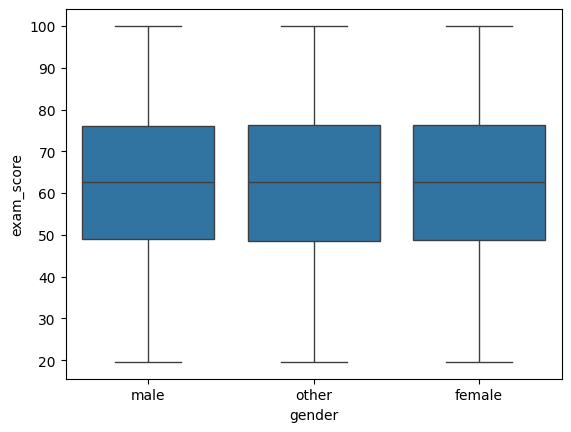

In [11]:
sns.boxplot(x="gender", y="exam_score", data=df)


<Axes: xlabel='exam_difficulty', ylabel='exam_score'>

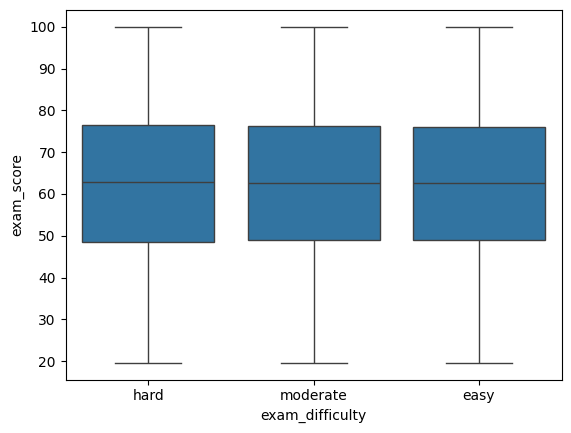

In [12]:
sns.boxplot(x="exam_difficulty", y="exam_score", data=df)


<Axes: xlabel='study_method', ylabel='exam_score'>

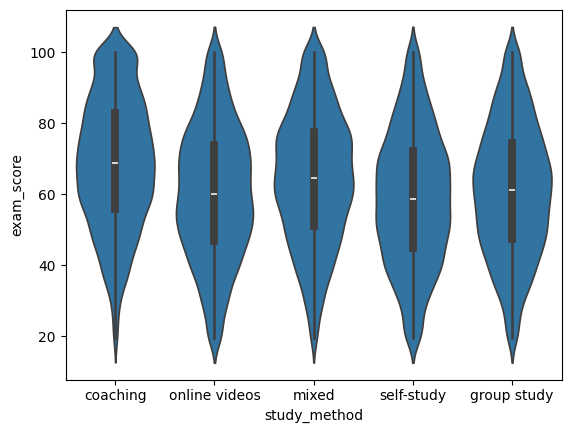

In [13]:
sns.violinplot(x="study_method", y="exam_score", data=df)


<Axes: xlabel='study_method', ylabel='exam_score'>

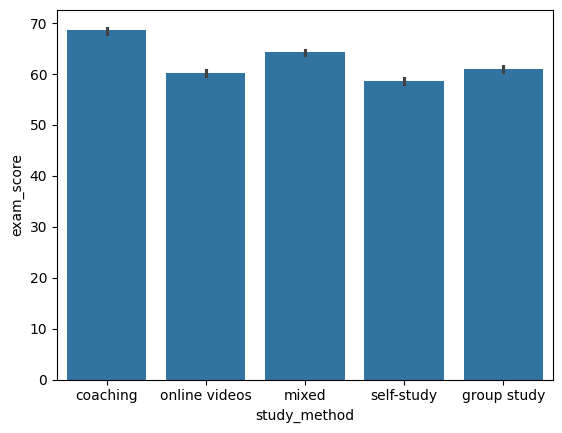

In [14]:
sns.barplot(x="study_method", y="exam_score", data=df)


<Axes: xlabel='exam_difficulty', ylabel='exam_score'>

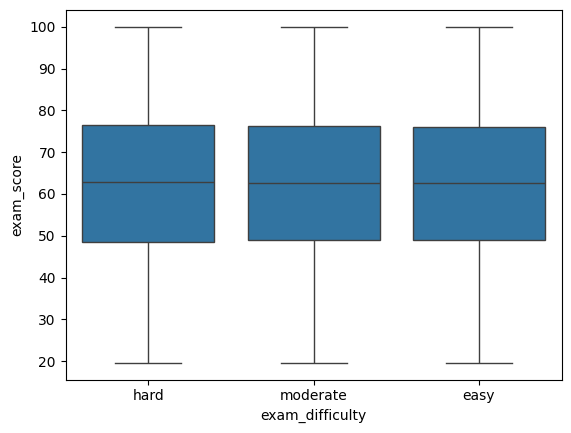

In [15]:
sns.boxplot(x="exam_difficulty", y="exam_score", data=df)


<Axes: xlabel='facility_rating', ylabel='exam_score'>

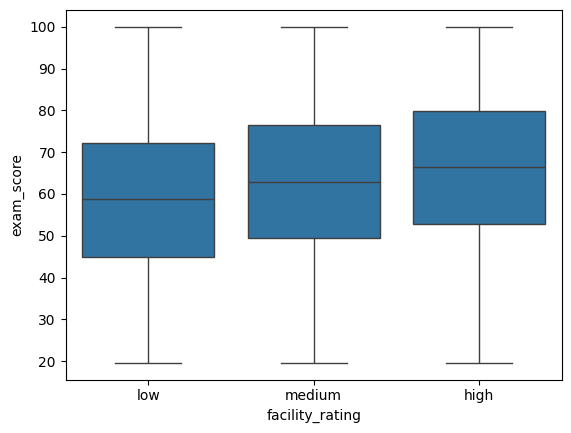

In [16]:
sns.boxplot(x="facility_rating", y="exam_score", data=df)


<Axes: xlabel='sleep_quality', ylabel='exam_score'>

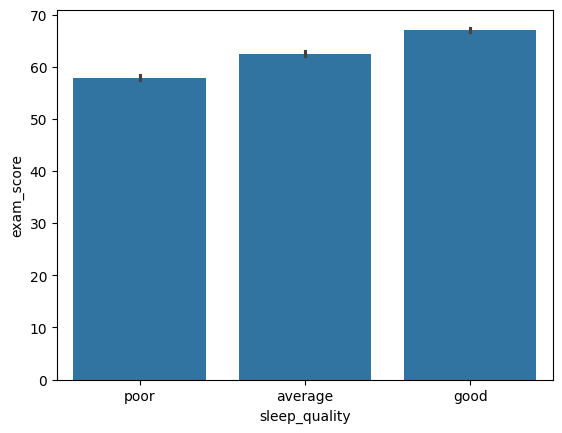

In [17]:
sns.barplot(x="sleep_quality", y="exam_score", data=df)


changing values to 0 1 

In [18]:
df["gender"] = df["gender"].map({
    "male": 1,
    "female": 0,
    "other": 2
})


In [19]:
df["internet_access"] = df["internet_access"].map({
    "yes": 1,
    "no": 0
})


In [20]:
df["sleep_quality"] = df["sleep_quality"].map({
    "good": 0,
    "average": 1,
    "poor": 2
})


In [21]:
df["exam_difficulty"] = df["exam_difficulty"].map({
    "easy": 0,
    "moderate": 1,
    "hard": 2
})


In [22]:
df["facility_rating"] = df["facility_rating"].map({
   "low": 0,
    "medium": 1,
    "high": 2
})


In [23]:
df["study_method"] = df["study_method"].map({
    "self-study": 0,
    "coaching": 1,
    "group study": 2,
    "online videos": 3
   })

trying to split 

In [66]:
x = df.drop("exam_score", axis=1)
y = df["exam_score"]


In [67]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(16000, 12)
(4000, 12)
(16000,)
(4000,)


In [84]:
print(df.columns)


Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')


In [85]:
X = df[['study_hours', 'class_attendance', 'sleep_hours']]
y = df['exam_score']


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Intercept: 4.912235358756966
Coefficients: [5.87139769 0.34409351 1.42296126]
MSE: 132.49135204262817
R² Score: 0.629598947036867
